In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()

df = pd.read_csv(output_dir / "datasets_tidy.csv")
pivot = df.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
datasets_list = df["dataset"].unique().tolist()

print(f"Loaded {len(datasets_list)} dataset(s)")

Loaded 2 dataset(s)


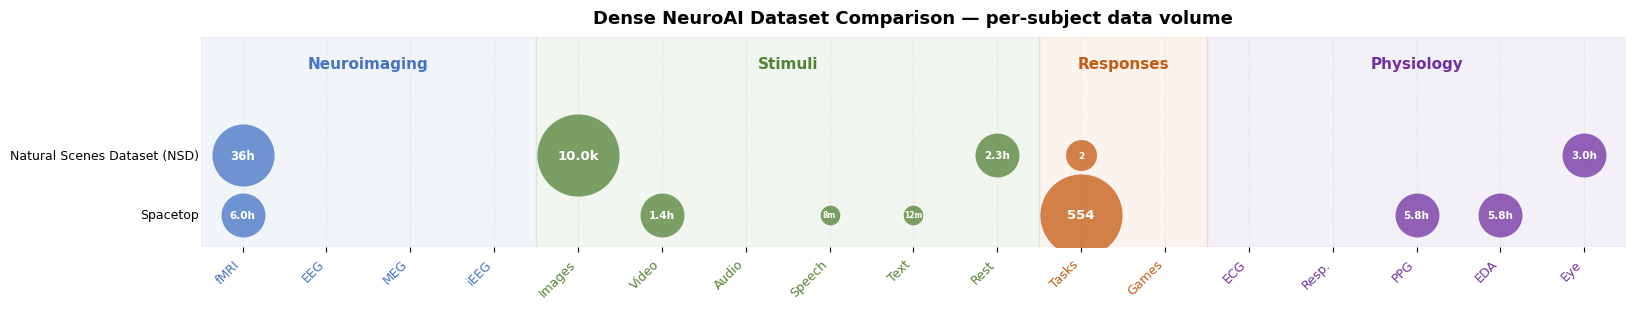

Saved dataset_comparison.png


In [2]:
# Column groups: (group_name, color, [(label, dotpath, unit), ...])
# unit 'h'     = hours, sized by HOUR_TIERS
# unit '#img'  = image count, sized by IMAGE_TIERS
# unit '#cond' = condition count, sized by COND_TIERS
COLUMN_GROUPS = [
    ("Neuroimaging", "#4472C4", [
        ("fMRI",  "neuroimaging.fmri.per_subject_h",  "h"),
        ("EEG",   "neuroimaging.eeg.per_subject_h",   "h"),
        ("MEG",   "neuroimaging.meg.per_subject_h",   "h"),
        ("iEEG",  "neuroimaging.ieeg.per_subject_h",  "h"),
    ]),
    ("Stimuli", "#538135", [
        ("Images", "naturalistic_stimuli.images.per_subject_unique",           "#img"),
        ("Video",  "naturalistic_stimuli.video.per_subject_unique",            "h"),
        ("Audio",  "naturalistic_stimuli.audio.per_subject_unique",            "h"),
        ("Speech", "naturalistic_stimuli.speech_listening.per_subject_unique", "h"),
        ("Text",   "naturalistic_stimuli.text_reading.per_subject_unique",     "h"),
        ("Rest",   "naturalistic_stimuli.resting_state.per_subject_unique",    "h"),
    ]),
    ("Responses", "#C55A11", [
        ("Tasks", "responses.controlled_tasks.per_subject_unique", "#cond"),
        ("Games", "responses.game_actions.per_subject_unique",     "h"),
    ]),
    ("Physiology", "#7030A0", [
        ("ECG",   "physiology.ecg.per_subject_unique",            "h"),
        ("Resp.", "physiology.respiration.per_subject_unique",    "h"),
        ("PPG",   "physiology.plethysmograph.per_subject_unique", "h"),
        ("EDA",   "physiology.eda.per_subject_unique",            "h"),
        ("Eye",   "physiology.eye_tracking.per_subject_unique",   "h"),
    ]),
]

# Bubble size tiers: (upper_bound, scatter_s, fontsize, legend_label)
# Hours (h)
HOUR_TIERS = [
    (20 / 60,      200,  5.5, "ultra small\n(<20 min)"),
    (1,            500,  6.5, "small\n(<1 h)"),
    (10,          1000,  7.5, "medium\n(<10 h)"),
    (50,          2000,  8.5, "big\n(<50 h)"),
    (float("inf"), 3500, 9.5, "ultra big\n(≥50 h)"),
]
# Image counts (#img)
IMAGE_TIERS = [
    (1000,         500,  6.5, "small\n(<1k)"),
    (5000,        1000,  7.5, "medium\n(<5k)"),
    (10000,       2000,  8.5, "big\n(<10k)"),
    (float("inf"), 3500, 9.5, "ultra big\n(≥10k)"),
]
# Condition counts (#cond)
COND_TIERS = [
    (10,           500,  6.5, "small\n(<10)"),
    (100,         1000,  7.5, "medium\n(<100)"),
    (500,         2000,  8.5, "big\n(<500)"),
    (float("inf"), 3500, 9.5, "ultra big\n(≥500)"),
]

TIER_MAP = {"h": HOUR_TIERS, "#img": IMAGE_TIERS, "#cond": COND_TIERS}


def value_to_bubble(value, unit):
    """Return (scatter_s, fontsize) for a value/unit pair."""
    for upper, s, fs, _ in TIER_MAP[unit]:
        if value < upper:
            return s, fs
    return TIER_MAP[unit][-1][1], TIER_MAP[unit][-1][2]


def fmt(value, unit):
    if unit in ("#img", "#cond"):
        return f"{value / 1000:.1f}k" if value >= 1000 else str(int(value))
    if value >= 10:
        return f"{value:.0f}h"
    if value >= 1:
        return f"{value:.1f}h"
    return f"{value * 60:.0f}m"


# Flatten columns and track group spans
all_cols = []     # (label, path, unit, color)
group_spans = []  # (name, color, start_col, end_col)
for group_name, color, fields in COLUMN_GROUPS:
    start = len(all_cols)
    for label, path, unit in fields:
        all_cols.append((label, path, unit, color))
    group_spans.append((group_name, color, start, len(all_cols) - 1))
n_cols = len(all_cols)

# Sort datasets by per-subject fMRI hours descending; no-fMRI datasets go last
fmri_col = "neuroimaging.fmri.per_subject_h"
fmri_hours = pivot[fmri_col] if fmri_col in pivot.columns else pd.Series(dtype=float)
datasets_sorted = sorted(datasets_list, key=lambda d: fmri_hours.get(d, 0) or 0, reverse=True)
n_ds = len(datasets_sorted)

# --- Figure layout ---
COL_W, ROW_H = 0.78, 0.80
LABEL_W = 3.2
HEADER_H = 1.6

fig, ax = plt.subplots(figsize=(LABEL_W + n_cols * COL_W, HEADER_H + n_ds * ROW_H))

# Background bands per group
for gname, color, c0, c1 in group_spans:
    ax.axvspan(c0 - 0.5, c1 + 0.5, color=color, alpha=0.07, zorder=0)

# Group header labels
for gname, color, c0, c1 in group_spans:
    ax.text((c0 + c1) / 2, n_ds + 0.55, gname,
            ha="center", va="center", fontsize=11, fontweight="bold", color=color)

# Column labels (x-ticks, colored by group)
ax.set_xticks(range(n_cols))
ax.set_xticklabels([c[0] for c in all_cols], rotation=45, ha="right", fontsize=9)
for tick, (_, _, _, color) in zip(ax.get_xticklabels(), all_cols):
    tick.set_color(color)

# Dataset rows: name label + bubbles
for row_i, ds_name in enumerate(datasets_sorted):
    y = n_ds - 1 - row_i
    ax.text(-0.52, y, ds_name, ha="right", va="center", fontsize=9)
    for col_j, (label, path, unit, color) in enumerate(all_cols):
        if path not in pivot.columns:
            continue
        value = pivot.loc[ds_name, path]
        if pd.isna(value) or value == 0:
            continue
        s, fs = value_to_bubble(value, unit)
        ax.scatter(col_j, y, s=s, color=color, alpha=0.75, linewidths=0, zorder=3)
        ax.text(col_j, y, fmt(value, unit),
                ha="center", va="center", fontsize=fs, fontweight="bold",
                color="white", zorder=4)

# Axes styling
ax.set_yticks([])
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-0.55, n_ds + 1.0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)
ax.set_title("Dense NeuroAI Dataset Comparison — per-subject data volume",
             fontsize=13, fontweight="bold", pad=10)

plt.tight_layout()
fig.savefig(output_dir / "dataset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved dataset_comparison.png")

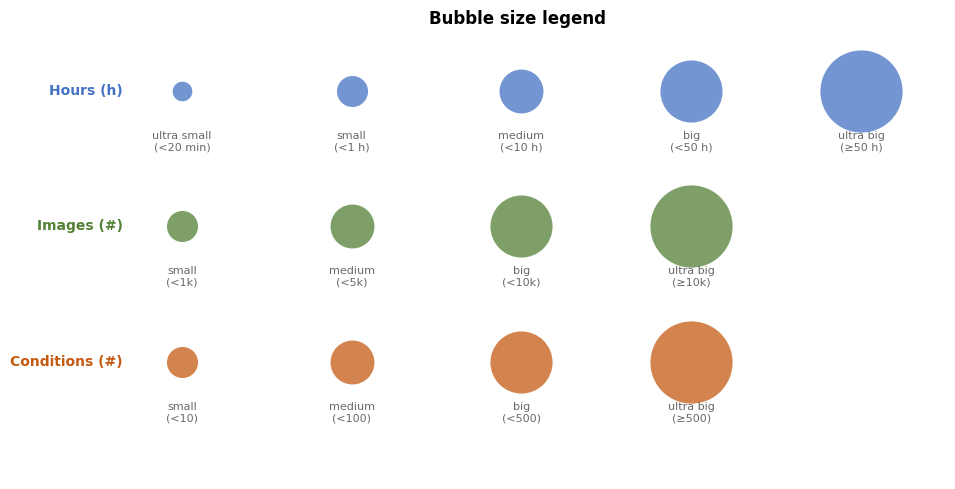

Saved dataset_comparison_legend.png


In [3]:
# --- Standalone legend figure ---
TIER_SETS = [
    ("Hours (h)",       HOUR_TIERS,  "#4472C4"),
    ("Images (#)",      IMAGE_TIERS, "#538135"),
    ("Conditions (#)",  COND_TIERS,  "#C55A11"),
]

n_sets = len(TIER_SETS)
max_n = max(len(tiers) for _, tiers, _ in TIER_SETS)
COL_SP = 2.0    # horizontal spacing between bubbles (data units)
ROW_SP = 2.2    # vertical spacing between tier sets (data units)
LABEL_OFF = 0.65  # label y-offset below bubble center

fig_w = 2.2 + max_n * COL_SP * 0.75
fig_h = n_sets * ROW_SP * 0.65 + 0.7

fig_leg, ax_leg = plt.subplots(figsize=(fig_w, fig_h))
ax_leg.set_xlim(-1.1, (max_n - 0.5) * COL_SP)
ax_leg.set_ylim(-0.8, n_sets * ROW_SP - 0.2)
ax_leg.set_axis_off()
ax_leg.set_title("Bubble size legend", fontsize=12, fontweight="bold", pad=8)

for set_i, (set_name, tiers, color) in enumerate(TIER_SETS):
    y = (n_sets - 1 - set_i) * ROW_SP + ROW_SP / 2
    ax_leg.text(-0.7, y, set_name, ha="right", va="center",
                fontsize=10, fontweight="bold", color=color)
    for col_j, (upper, s, fs, lbl) in enumerate(tiers):
        x = col_j * COL_SP
        ax_leg.scatter(x, y, s=s, color=color, alpha=0.75, linewidths=0, zorder=3)
        ax_leg.text(x, y - LABEL_OFF, lbl,
                    ha="center", va="top", fontsize=8, color="dimgray")

plt.tight_layout()
fig_leg.savefig(output_dir / "dataset_comparison_legend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved dataset_comparison_legend.png")